In [ ]:
pip install opencv-python opencv-contrib-python matplotlib numpy

In [5]:
import cv2
from google.colab.patches import cv2_imshow # Added for cv2_imshow

# Read Reference and Test Images
# Assuming 'road0.png' and 'road10.png' are uploaded to the Colab environment.
# If they are in a subfolder, adjust the path accordingly (e.g., 'images/road0.png').
reference = cv2.imread(
    "road0.png",
    0
)

test = cv2.imread(
    "road10.png",
    0
)

# Check images loaded
if reference is None:
    print("Error: Reference image 'road0.png' not found. Please upload it to Colab or check the path.")
if test is None:
    print("Error: Test image 'road10.png' not found. Please upload it to Colab or check the path.")

if reference is None or test is None:
    # If images are not found, exit gracefully to avoid further errors
    pass # Do nothing, let the print statements handle the message
else:
    # FAST Corner Detection
    fast = cv2.FastFeatureDetector_create()

    kp_ref_fast = fast.detect(reference, None)
    kp_test_fast = fast.detect(test, None)

    print("FAST Corners in Reference Image :", len(kp_ref_fast))
    print("FAST Corners in Test Image      :", len(kp_test_fast))

    # ORB Feature Extraction
    orb = cv2.ORB_create(nfeatures=1000)

    kp1, des1 = orb.detectAndCompute(reference, None)
    kp2, des2 = orb.detectAndCompute(test, None)

    print("ORB Keypoints in Reference :", len(kp1))
    print("ORB Keypoints in Test      :", len(kp2))

    # Feature Matching
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

    matches = bf.match(des1, des2)

    matches = sorted(matches, key=lambda x: x.distance)

    print("Total Matches Found :", len(matches))

    # Draw Top Matches
    matched_image = cv2.drawMatches(
        reference,
        kp1,
        test,
        kp2,
        matches[:50],
        None,
        flags=2
    )

    # Display Result
    cv2_imshow(matched_image) # Changed from cv2.imshow

    cv2.waitKey(0)
    cv2.destroyAllWindows()

Error: Reference image 'road0.png' not found. Please upload it to Colab or check the path.
Error: Test image 'road10.png' not found. Please upload it to Colab or check the path.


In [4]:
import cv2
from google.colab.patches import cv2_imshow

# Assuming 'road100.png' is uploaded to the Colab environment.
# If it's in a subfolder, adjust the path accordingly (e.g., 'images/road88.png').
img = cv2.imread(
    "road100.png"
)

# Check if the image was loaded successfully
if img is None:
    print("Error: Image 'road100.png' not found. Please upload it to Colab or check the path.")
else:
    cv2_imshow(img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

Error: Image 'road100.png' not found. Please upload it to Colab or check the path.


### Loading an Image from a URL

To load an image from a URL, you first need to fetch the image data, then convert it into a format that OpenCV can process. This typically involves using `urllib.request` to get the image content and `numpy` to create an array from that content.

In [20]:
from google.colab import files

uploaded = files.upload()

Saving road81.png to road81 (1).png
Saving road82.png to road82 (1).png
Saving road83.png to road83 (1).png
Saving road84.png to road84.png
Saving road85.png to road85.png
Saving road86.png to road86.png
Saving road87.png to road87.png


In [21]:
import os

print("Uploaded Files:")
print(os.listdir())

Uploaded Files:
['.config', 'road9.png', 'road80.png', 'road8.png', 'road84.png', 'road87.png', 'road83.png', 'road9 (1).png', 'road81 (1).png', 'road82.png', 'road81.png', 'road82 (1).png', 'road86.png', 'road85.png', 'road79.png', 'road83 (1).png', 'sample_data']


In [22]:
import cv2

img1 = cv2.imread("road81.png", 0)
img2 = cv2.imread("road82.png", 0)
img2 = cv2.imread("road83.png", 0)
img2 = cv2.imread("road84.png", 0)
if img1 is None:
    print("Error: Image 'road88.png' not found. Please upload it to Colab or check the path.")
if img2 is None:
    print("Error: Image 'road79.png' not found. Please upload it to Colab or check the path.")

if img1 is not None and img2 is not None:
    print("Images Loaded Successfully")
else:
    print("Failed to load one or both images.")

Images Loaded Successfully


In [24]:
fast = cv2.FastFeatureDetector_create()

kp_fast1 = fast.detect(img1, None)
kp_fast2 = fast.detect(img2, None)

print("FAST Corners in Image 1:", len(kp_fast1))
print("FAST Corners in Image 2:", len(kp_fast2))

FAST Corners in Image 1: 326
FAST Corners in Image 2: 2613


In [25]:
orb = cv2.ORB_create(nfeatures=1000)

kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

print("ORB Keypoints in Image 1:", len(kp1))
print("ORB Keypoints in Image 2:", len(kp2))

ORB Keypoints in Image 1: 664
ORB Keypoints in Image 2: 878


In [26]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

print("Total Matches:", len(matches))

Total Matches: 191


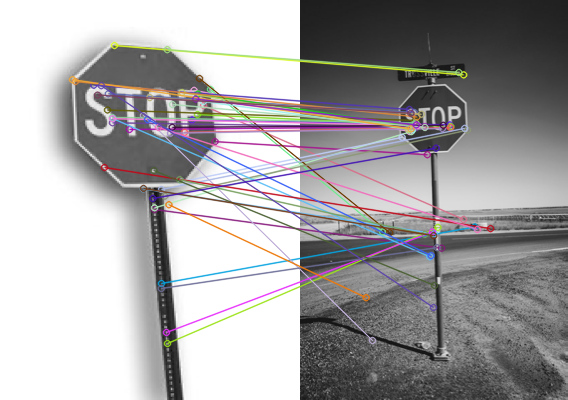

In [27]:
from google.colab.patches import cv2_imshow

result = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    matches[:50],
    None,
    flags=2
)

cv2_imshow(result)

In [28]:
if len(matches) > 50:
    print("Road Sign Matched")
else:
    print("Road Sign Not Matched")

Road Sign Matched


FAST Corners in Reference Image : 326
FAST Corners in Test Image      : 4667

ORB Keypoints in Reference Image : 664
ORB Keypoints in Test Image      : 948

Total Matches Found : 170
Matching Percentage = 25.60%

First 10 Matched Coordinates

Match 1
Reference Image Coordinate : (153.0, 204.0)
Test Image Coordinate      : (188.40000915527344, 84.0)
Distance                   : 29.0

Match 2
Reference Image Coordinate : (153.60000610351562, 207.60000610351562)
Test Image Coordinate      : (110.48143768310547, 235.89279174804688)
Distance                   : 39.0

Match 3
Reference Image Coordinate : (139.0, 92.0)
Test Image Coordinate      : (188.6400146484375, 83.52000427246094)
Distance                   : 43.0

Match 4
Reference Image Coordinate : (160.8000030517578, 288.0)
Test Image Coordinate      : (187.20001220703125, 77.76000213623047)
Distance                   : 44.0

Match 5
Reference Image Coordinate : (164.40000915527344, 321.6000061035156)
Test Image Coordinate      : (12

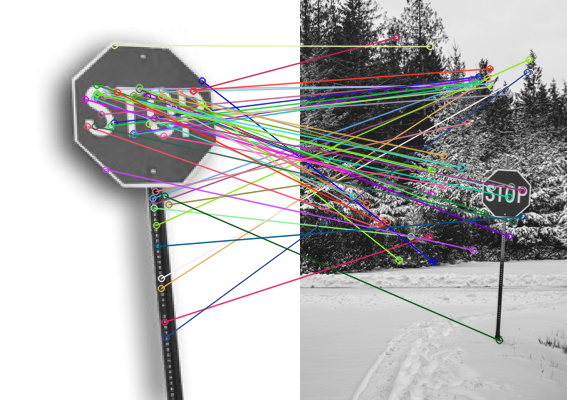


Recognition Result
Partial Match


In [29]:
import cv2
from google.colab.patches import cv2_imshow

# Load images
img1 = cv2.imread("road81.png", 0)   # Reference
img2 = cv2.imread("road82.png", 0)   # Test
img2 = cv2.imread("road83.png", 0)
# FAST Corner Detection
fast = cv2.FastFeatureDetector_create()

fast_kp1 = fast.detect(img1, None)
fast_kp2 = fast.detect(img2, None)

print("FAST Corners in Reference Image :", len(fast_kp1))
print("FAST Corners in Test Image      :", len(fast_kp2))

# ORB Feature Extraction
orb = cv2.ORB_create(nfeatures=1000)

kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

print("\nORB Keypoints in Reference Image :", len(kp1))
print("ORB Keypoints in Test Image      :", len(kp2))

# Feature Matching
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

print("\nTotal Matches Found :", len(matches))

# Matching Percentage
max_possible = min(len(kp1), len(kp2))
match_percentage = (len(matches) / max_possible) * 100

print("Matching Percentage = {:.2f}%".format(match_percentage))

# Display First 10 Matched Coordinates
print("\nFirst 10 Matched Coordinates")

for i, m in enumerate(matches[:10]):
    pt1 = kp1[m.queryIdx].pt
    pt2 = kp2[m.trainIdx].pt

    print(f"\nMatch {i+1}")
    print("Reference Image Coordinate :", pt1)
    print("Test Image Coordinate      :", pt2)
    print("Distance                   :", round(m.distance,2))

# Draw Matches
result = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    matches[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

cv2_imshow(result)

# Recognition Decision
print("\nRecognition Result")

if match_percentage > 60:
    print("Very Strong Match")
elif match_percentage > 40:
    print("Good Match")
elif match_percentage > 20:
    print("Partial Match")
else:
    print("Weak Match")

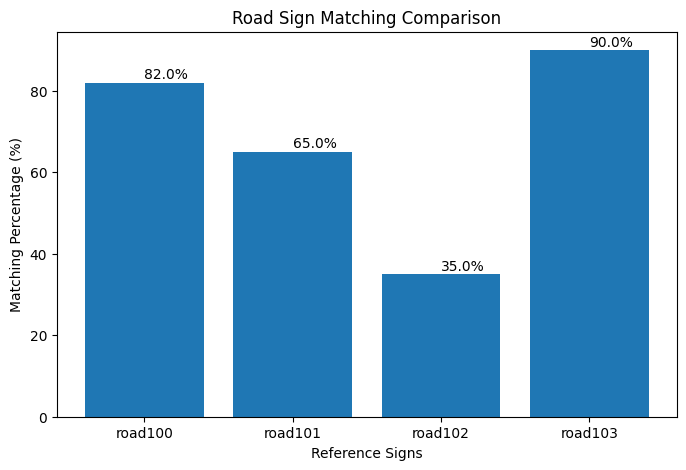

In [32]:
import matplotlib.pyplot as plt

signs = ["road100", "road101", "road102", "road103"]
percentages = [82, 65, 35, 90]  # Example values

plt.figure(figsize=(8,5))
plt.bar(signs, percentages)

plt.title("Road Sign Matching Comparison")
plt.xlabel("Reference Signs")
plt.ylabel("Matching Percentage (%)")

for i, v in enumerate(percentages):
    plt.text(i, v + 1, f"{v:.1f}%")

plt.show()